In [1]:
# 1. Verify that *jupyter* is running in the correct environment, as the backend is if it shows `.../venv/Scripts/python.exe`
import sys
print(sys.executable)

C:\Users\Administrator\Documents\git\Anas\rug-pull-detector-ml\venv\Scripts\python.exe


In [16]:
# 2. Import all the libs that we need
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from collections import Counter
import joblib
from sklearn.metrics import classification_report

In [3]:
# 3. Get the dataset
df = pd.read_csv("./ethereum_fraud_dataset.csv")

In [4]:
# 4. Fill missing values
df = df.fillna(0)

In [5]:
# 5. Shuffle dataset (unordered flag values (0s and 1s))
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [6]:
# 6. Split features and target
X = df.drop("FLAG", axis=1)
y = df["FLAG"]

In [7]:
# 6. Find the ratio of fraud and legit
fraud_count = y.value_counts()[1]
legit_count = y.value_counts()[0]
total = len(df)

fraud_percentage = (fraud_count / total) * 100
legit_percentage = (legit_count / total) * 100

print(f"Fraud Wallets: {fraud_count} ({fraud_percentage:.2f}%)")
print(f"Legit Wallets: {legit_count} ({legit_percentage:.2f}%)")

Fraud Wallets: 2179 (22.14%)
Legit Wallets: 7662 (77.86%)


In [8]:
# 8. Apply SMOTE
smote = SMOTE(
    sampling_strategy=0.67,  # Fraud becomes ~40% compared to legit
    random_state=42
)

X_resampled, y_resampled = smote.fit_resample(X, y)

# After SMOTE counts
after_counts = Counter(y_resampled)

after_legit = after_counts[0]
after_fraud = after_counts[1]
after_total = after_legit + after_fraud

after_legit_percentage = (after_legit / after_total) * 100
after_fraud_percentage = (after_fraud / after_total) * 100

print("=== AFTER SMOTE ===")
print(f"Legit Wallets: {after_legit} ({after_legit_percentage:.2f}%)")
print(f"Fraud Wallets: {after_fraud} ({after_fraud_percentage:.2f}%)")

=== AFTER SMOTE ===
Legit Wallets: 7662 (59.88%)
Fraud Wallets: 5133 (40.12%)


In [9]:
# 9. Remove rows where ALL columns are 0
X_cleaned = X_resampled[(X_resampled != 0).any(axis=1)]

In [10]:
# 10. Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
X_resampled,
y_resampled,
test_size=0.3,
random_state=42,
stratify=y_resampled
)

In [11]:
# 11. Train model
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [12]:
# 12. Predict
y_pred = model.predict(X_test)

In [13]:
# 13. Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

Model Accuracy: 94.71%


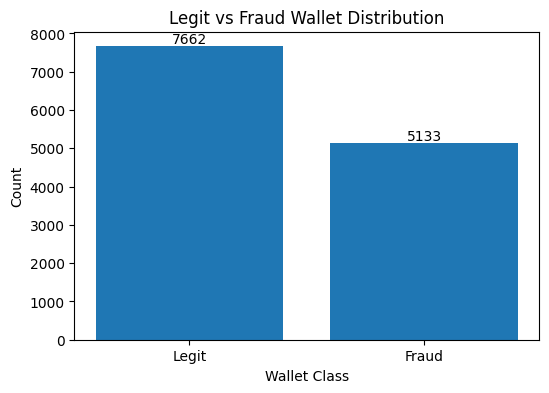

In [14]:
# 14. Count fraud and legit after SMOTE
class_counts = pd.Series(y_resampled).value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["Legit", "Fraud"], class_counts.values)

plt.title("Legit vs Fraud Wallet Distribution")
plt.xlabel("Wallet Class")
plt.ylabel("Count")

for i, value in enumerate(class_counts.values):
    plt.text(i, value, str(value), ha="center", va="bottom")

plt.show()

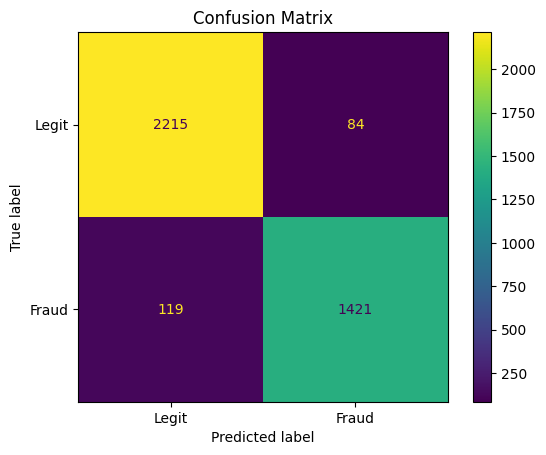

In [15]:
# 15. Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legit", "Fraud"]
)

disp.plot()
plt.title("Confusion Matrix")
plt.show()

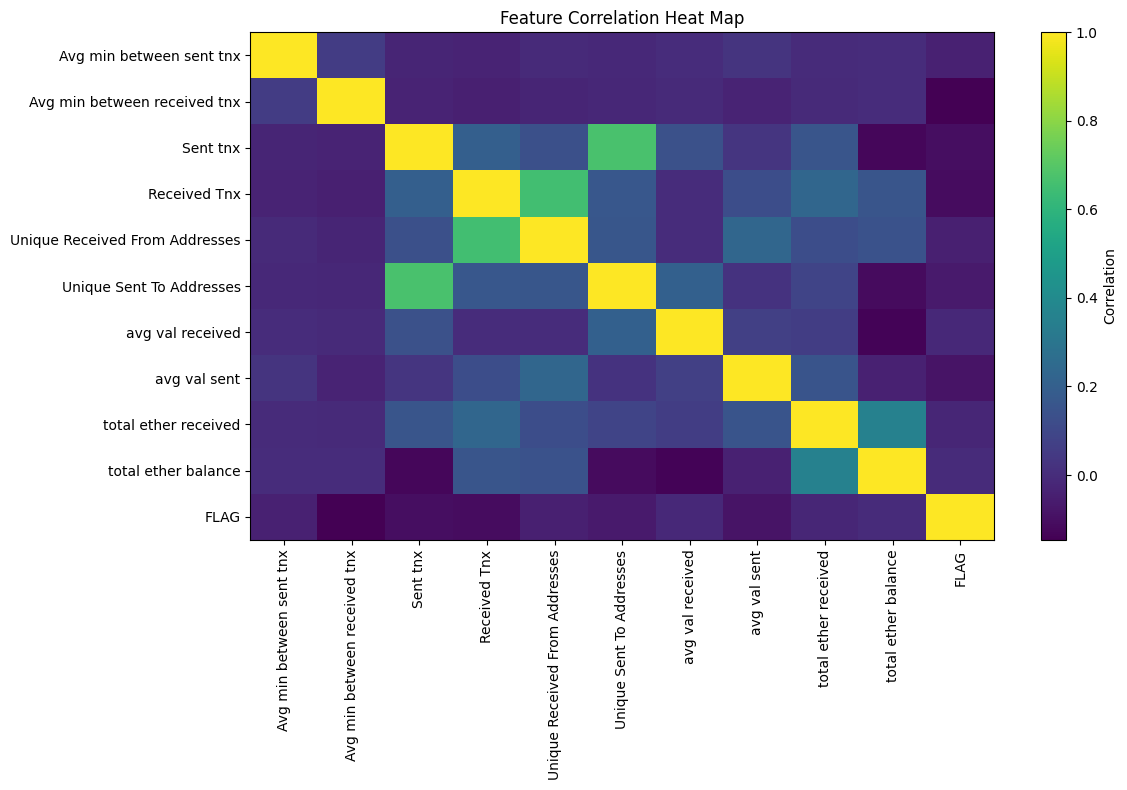

In [17]:
# 16. Combine features and target for correlation
corr_df = X_resampled.copy()
corr_df["FLAG"] = y_resampled

correlation_matrix = corr_df.corr()

plt.figure(figsize=(12, 8))
plt.imshow(correlation_matrix, aspect="auto")
plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Feature Correlation Heat Map")
plt.tight_layout()
plt.show()

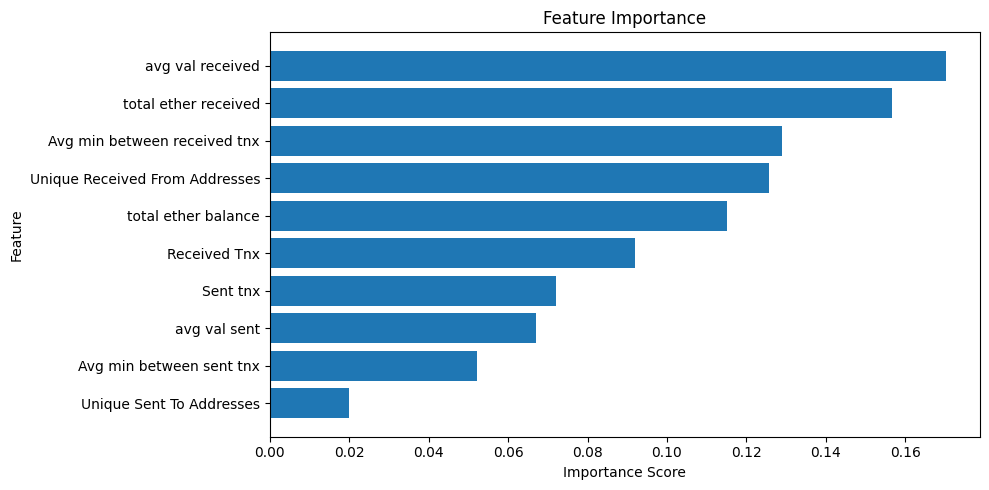

In [19]:
# 17. Feature importance plot
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10, 5))
plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [20]:
# 18. Accuracy / Classification Report
print(f"Model Accuracy: {accuracy * 100:.2f}%")

print(classification_report(
    y_test,
    y_pred,
    target_names=["Legit", "Fraud"]
))

Model Accuracy: 94.71%
              precision    recall  f1-score   support

       Legit       0.95      0.96      0.96      2299
       Fraud       0.94      0.92      0.93      1540

    accuracy                           0.95      3839
   macro avg       0.95      0.94      0.94      3839
weighted avg       0.95      0.95      0.95      3839



In [16]:
# 19. Save model
joblib.dump(model, "crypto_fraud_model.pkl")

['crypto_fraud_model.pkl']